In [1]:
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from transformers import ViTForImageClassification
from pathlib import Path

import sys; sys.path.append("../src/")
from stability import soft_stability_rate
from models import MaskedImageClassifier, CertifiedMuSImageClassifier
from data_utils import load_images_from_directory

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
images = load_images_from_directory(f"/home/antonxue/foo/data/imagenet_samples/imagenet_2_per_class/")
print(images.shape)

torch.Size([2000, 3, 224, 224])


In [3]:
num_samples = 100

images = images[:num_samples]
lime_exps = torch.load("_cache/imagenet_2_per_class/vit_lime.pt")[:num_samples]

In [4]:
raw_vit = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224")

cert_mus_vit = CertifiedMuSImageClassifier(raw_vit, lambda_=0.25)
cert_mus_vit.eval().to(device)

masked_vit = MaskedImageClassifier(raw_vit, grid_size=(14,14))
masked_vit.eval().to(device);

In [5]:
radii = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [6]:
images.shape, lime_exps.shape

(torch.Size([100, 3, 224, 224]), torch.Size([100, 14, 14]))

In [7]:
cert_rs = cert_mus_vit(images.to(device), lime_exps.to(device))["cert_rs"].cpu()

In [8]:
cert_rs

tensor([0.3438, 1.0000, 0.4375, 1.0938, 0.0625, 0.0000, 0.0938, 0.3750, 0.0312,
        1.3438, 0.5625, 0.5000, 0.6250, 0.0938, 0.2500, 0.0625, 0.2188, 0.0312,
        0.0938, 0.2500, 0.0312, 0.0625, 0.3125, 0.1250, 0.8750, 0.0938, 0.9062,
        0.0625, 0.4062, 0.3750, 0.0625, 1.3750, 1.3750, 0.0938, 0.0000, 0.8125,
        1.5312, 0.0938, 0.0312, 0.4062, 0.1562, 0.1250, 0.0938, 0.1250, 0.0000,
        0.2188, 0.7812, 0.0312, 0.2500, 0.0312, 0.8750, 0.4375, 1.0000, 0.2188,
        0.0000, 0.0938, 0.2500, 0.8125, 0.1562, 0.4375, 0.4375, 0.6250, 0.0312,
        0.3438, 0.0312, 0.0312, 0.4062, 0.4688, 0.7188, 0.7812, 0.0000, 0.0625,
        0.1875, 0.1875, 0.0312, 0.0312, 0.1250, 0.1250, 0.6562, 0.0625, 0.7812,
        0.1562, 0.3750, 1.0000, 0.0625, 0.0000, 0.0312, 0.0312, 0.3438, 0.0312,
        0.0000, 0.0625, 0.1562, 0.4062, 0.0000, 0.5625, 0.1250, 0.0312, 0.0312,
        0.0312])

In [9]:
soft_stab_rates = []

for img, exp in tqdm(zip(images, lime_exps)):
    this_rates = []
    for r in radii:
        stab_rate = soft_stability_rate(
            masked_vit, x=img.to(device), alpha=exp.to(device), radius=r, epsilon=0.1, delta=0.1
        )
        this_rates.append(stab_rate)
    soft_stab_rates.append(torch.tensor(this_rates))
soft_stab_rates = torch.stack(soft_stab_rates)

0it [00:00, ?it/s]

In [11]:
est_hard_stab_rs = []
for rates in soft_stab_rates:
    lt1_indices = torch.nonzero(rates < 1)
    if len(lt1_indices) > 0:
        first_index = lt1_indices[0].item()
        est_hard_stab_rs.append(radii[first_index])
    else:
        est_hard_stab_rs.append(radii[-1])
est_hard_stab_rs = torch.tensor(est_hard_stab_rs)

In [12]:
r_max = radii[-1]
r_ticks = torch.arange(start=0.0, end=r_max, step=0.1)
cum_cert_rs = torch.tensor([(cert_rs > rt).sum() / num_samples for rt in r_ticks])
cum_est_hard_rs = torch.tensor([(est_hard_stab_rs > rt).sum() / num_samples for rt in r_ticks])

<Figure size 640x480 with 0 Axes>

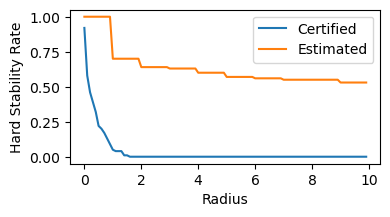

In [13]:
plt.clf()
fig, ax = plt.subplots(figsize=(4,2))
ax.plot(r_ticks.numpy(), cum_cert_rs, label="Certified")
ax.plot(r_ticks.numpy(), cum_est_hard_rs, label="Estimated")

ax.set_xlabel("Radius")
ax.set_ylabel("Hard Stability Rate")
ax.legend(loc="upper right")

plt.savefig("_dump/certified_vs_estimated_hard_stability_rates_vit_lime.pdf", bbox_inches="tight")